In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [44]:
df=pd.read_csv("cars_dataset.csv")

In [45]:
print("First 5 rows:")
print(df.head())

First 5 rows:
  model  year  price transmission  mileage fuelType    tax   mpg  engineSize  \
0    A1  2017  12500       Manual    15735   Petrol  150.0  55.4         1.4   
1    A6  2016  16500    Automatic    36203   Diesel   20.0  64.2         2.0   
2    A1  2016  11000       Manual    29946   Petrol   30.0  55.4         1.4   
3    A4  2017  16800    Automatic    25952   Diesel  145.0  67.3         2.0   
4    A3  2019  17300       Manual     1998   Petrol  145.0  49.6         1.0   

   Make  
0  audi  
1  audi  
2  audi  
3  audi  
4  audi  


In [46]:
print("/nDataset Info:")
print(df.info())

/nDataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72435 entries, 0 to 72434
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         72435 non-null  object 
 1   year          72435 non-null  int64  
 2   price         72435 non-null  int64  
 3   transmission  72435 non-null  object 
 4   mileage       72435 non-null  int64  
 5   fuelType      72435 non-null  object 
 6   tax           72435 non-null  float64
 7   mpg           72435 non-null  float64
 8   engineSize    72435 non-null  float64
 9   Make          72435 non-null  object 
dtypes: float64(3), int64(3), object(4)
memory usage: 5.5+ MB
None


In [47]:
print("/nDataset shape:")
print(df.shape)

/nDataset shape:
(72435, 10)


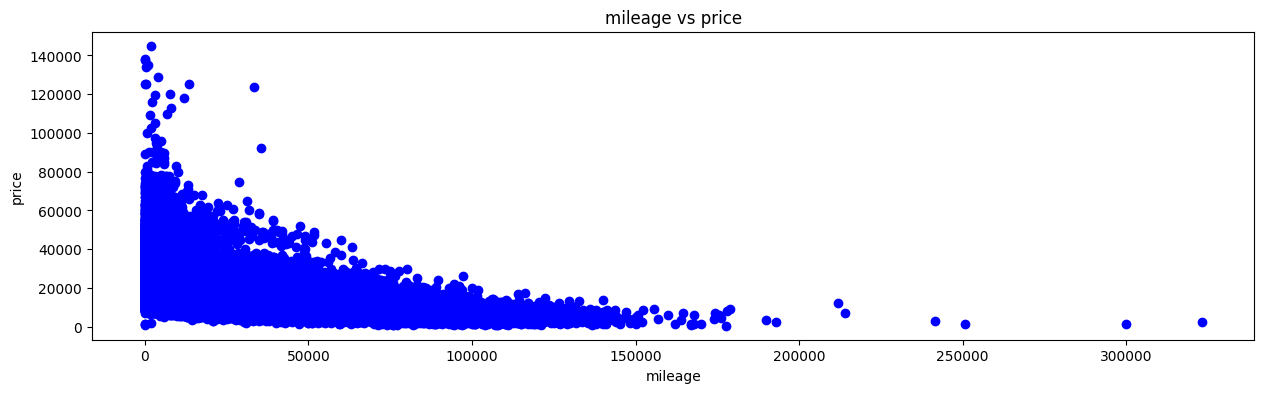

In [48]:
from ipywidgets.widgets.widget_int import Color
plt.figure(figsize=(15,4))
plt.scatter(df["mileage"], df["price"],
color = "blue")
plt.xlabel("mileage")
plt.ylabel("price")
plt.title("mileage vs price")
plt.show()

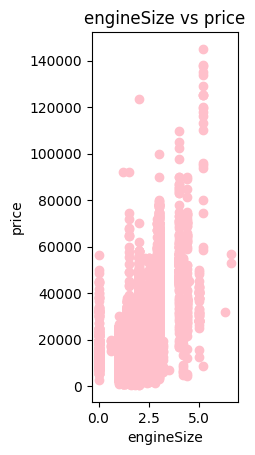

In [49]:
plt.subplot(1,3,1)
plt.scatter(df['engineSize'],df['price'],color='pink')
plt.xlabel('engineSize')
plt.ylabel('price')
plt.title('engineSize vs price')
plt.show()

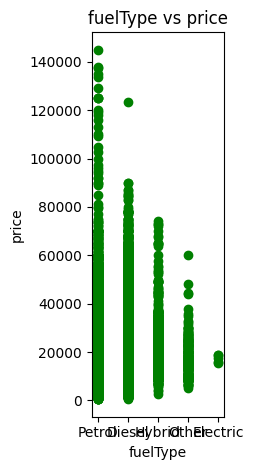

In [50]:
plt.subplot(1,3,3)
plt.scatter(df['fuelType'],df['price'],color='green')
plt.xlabel('fuelType')
plt.ylabel('price')
plt.title('fuelType vs price')
plt.tight_layout()

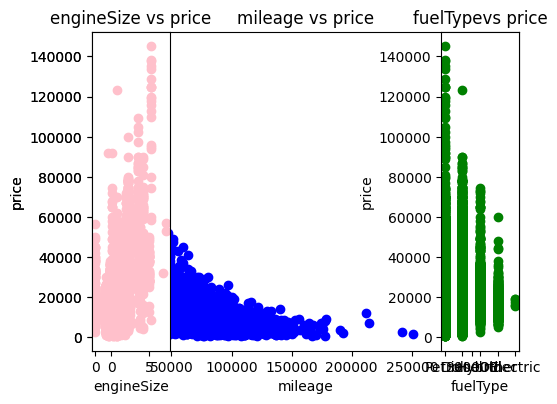

In [51]:
plt.scatter(df["mileage"], df["price"],
color = "blue")
plt.xlabel("mileage")
plt.ylabel("price")
plt.title("mileage vs price")
plt.subplot(1,3,1)
plt.scatter(df['engineSize'],df['price'],color='pink')
plt.xlabel('engineSize')
plt.ylabel('price')
plt.title('engineSize vs price')
plt.subplot(1,3,3)
plt.scatter(df['fuelType'],df['price'],color='green')
plt.xlabel('fuelType')
plt.ylabel('price')
plt.title('fuelTypevs price')
plt.tight_layout()
plt.show()

/nCorrelation Matrix:
                year     price   mileage       tax       mpg  engineSize
year        1.000000  0.519459 -0.747270  0.244933 -0.144384   -0.028511
price       0.519459  1.000000 -0.426925  0.353244 -0.334174    0.629251
mileage    -0.747270 -0.426925  1.000000 -0.234098  0.179153    0.122965
tax         0.244933  0.353244 -0.234098  1.000000 -0.423287    0.294148
mpg        -0.144384 -0.334174  0.179153 -0.423287  1.000000   -0.282202
engineSize -0.028511  0.629251  0.122965  0.294148 -0.282202    1.000000


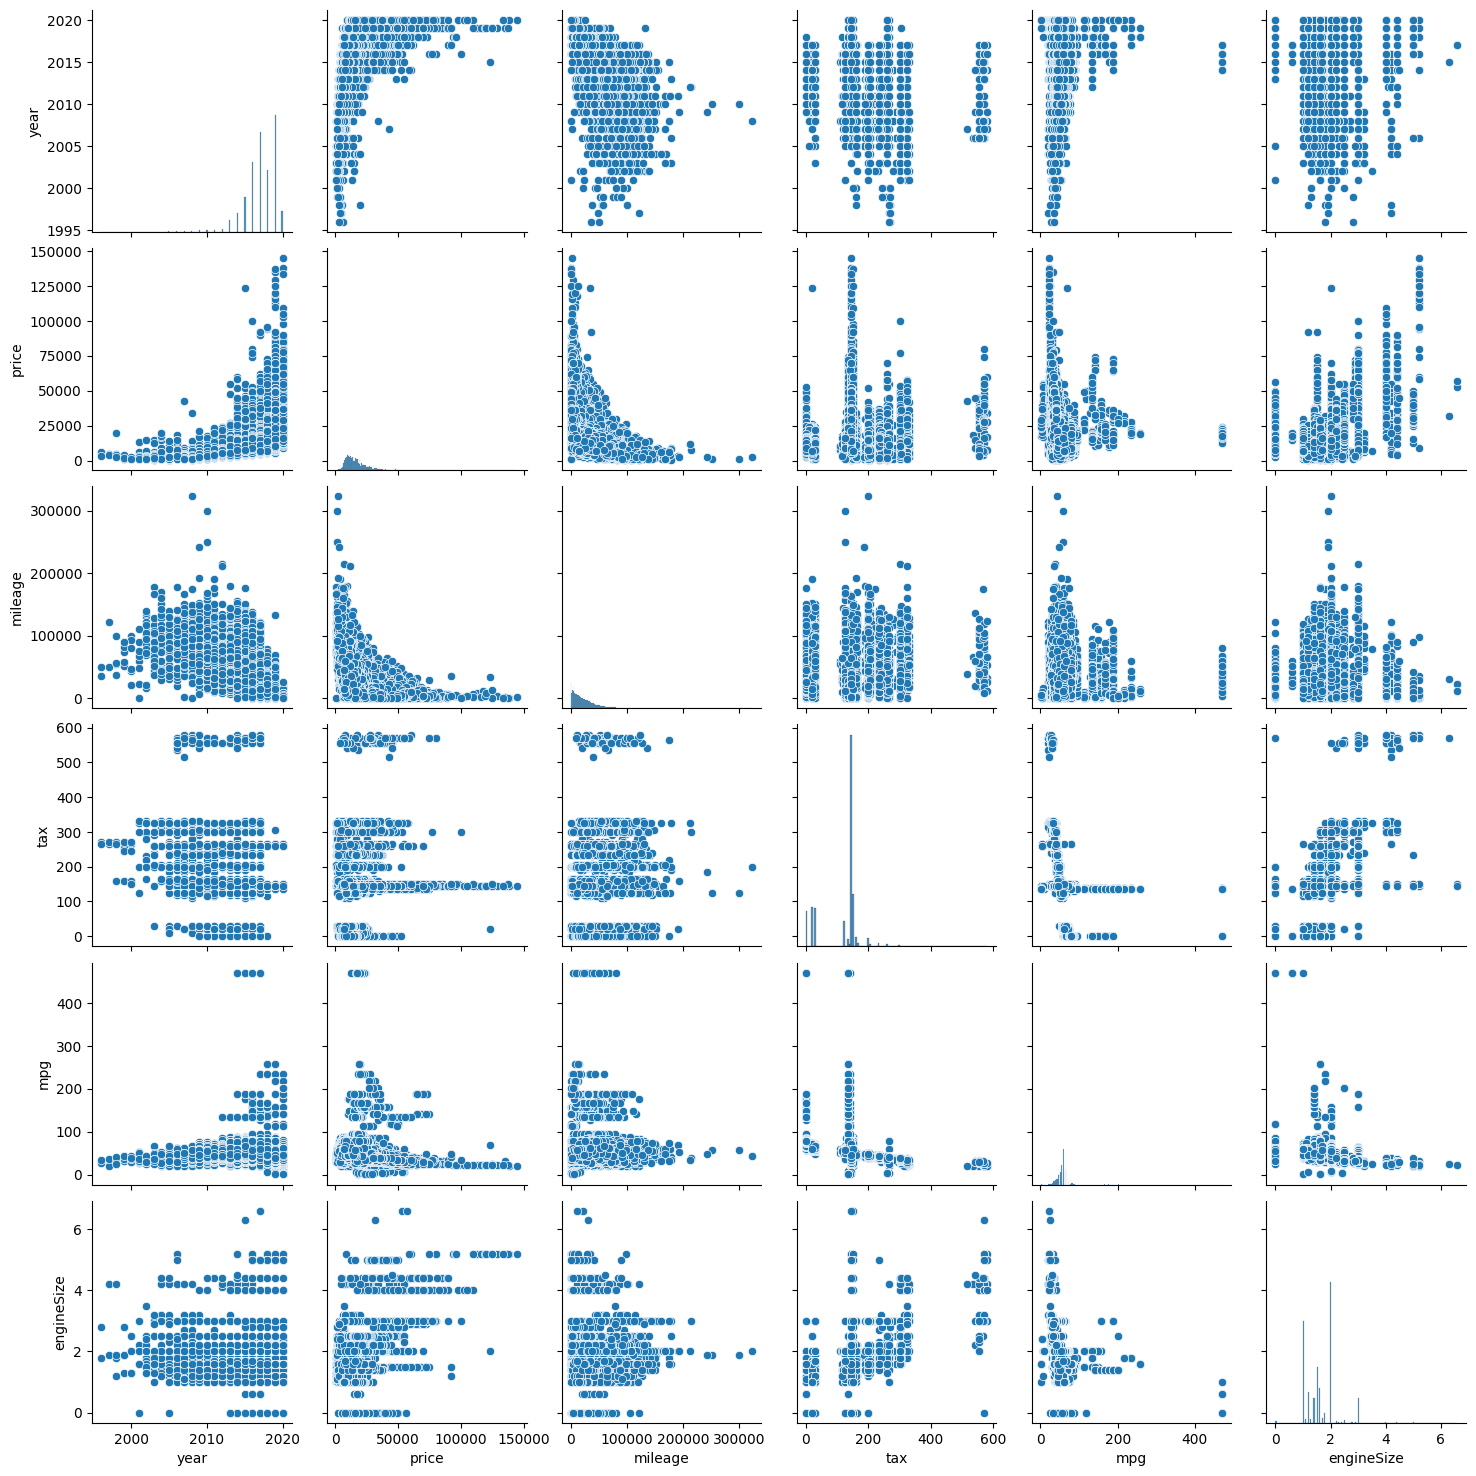

In [52]:
print("/nCorrelation Matrix:")
print(df.corr(numeric_only=True))

sns.pairplot(df)
plt.show()

In [53]:
X = df[["mileage", "engineSize", "fuelType"]]

y = df[["price"]]

print("\nType of X:", type(X))
print("Type of y:", type(y))

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.4,
    random_state=50
)

print("\nX_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)



Type of X: <class 'pandas.core.frame.DataFrame'>
Type of y: <class 'pandas.core.frame.DataFrame'>

X_train shape: (43461, 3)
X_test shape: (28974, 3)
y_train shape: (43461, 1)
y_test shape: (28974, 1)


In [60]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Separate numerical and categorical columns
numeric_features = ["mileage", "engineSize"]
categorical_features = ["fuelType"]

# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

# Fit on training data and transform
X_train = preprocessor.fit_transform(X_train)

# Transform test data using the same fitted preprocessor
X_test = preprocessor.transform(X_test)

print(X_train)

[[ 3.42497654  0.65455787  1.         ...  0.          0.
   0.        ]
 [-0.87354015 -0.41767394  0.         ...  0.          0.
   1.        ]
 [-0.61049231 -0.06026334  0.         ...  0.          0.
   1.        ]
 ...
 [ 0.27583081 -0.77508455  0.         ...  0.          0.
   1.        ]
 [-0.56032751 -1.13249516  0.         ...  0.          0.
   1.        ]
 [-1.08369633  0.65455787  0.         ...  0.          0.
   1.        ]]


In [61]:
from sklearn.linear_model import LinearRegression

regression = LinearRegression()
regression.fit(X_train,y_train)
print("/nnregression trained successfully!")

/nnregression trained successfully!


In [62]:
from sklearn.linear_model import LinearRegression
regression = LinearRegression()
regression.fit(X_train,y_train)
print("coefficent of slope",regression.coef_)
print("coefficent of slope",regression.intercept_)

coefficent of slope [[-4661.45932803  6727.32448784 -1612.37167724  1019.2150568
   -147.9811488   1379.49803547  -638.36026623]]
coefficent of slope [17551.25901739]
